# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('./data/retailmax.csv')

### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

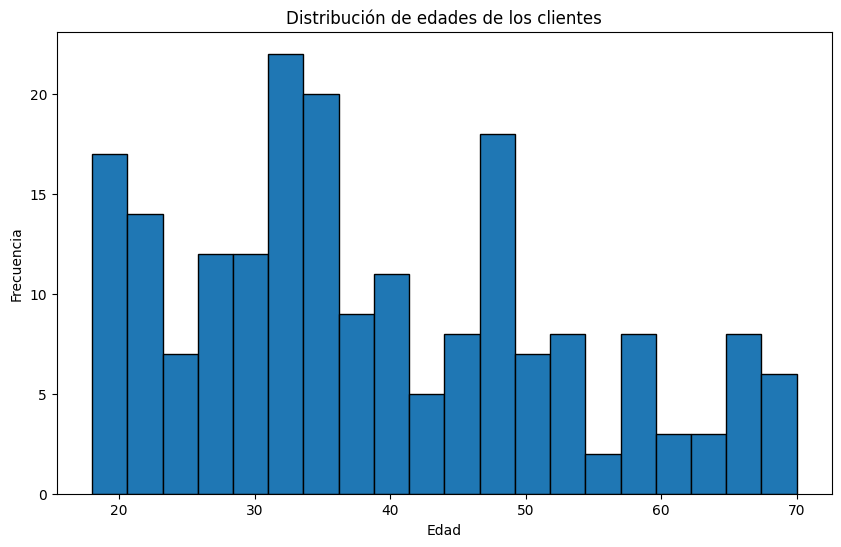

In [2]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

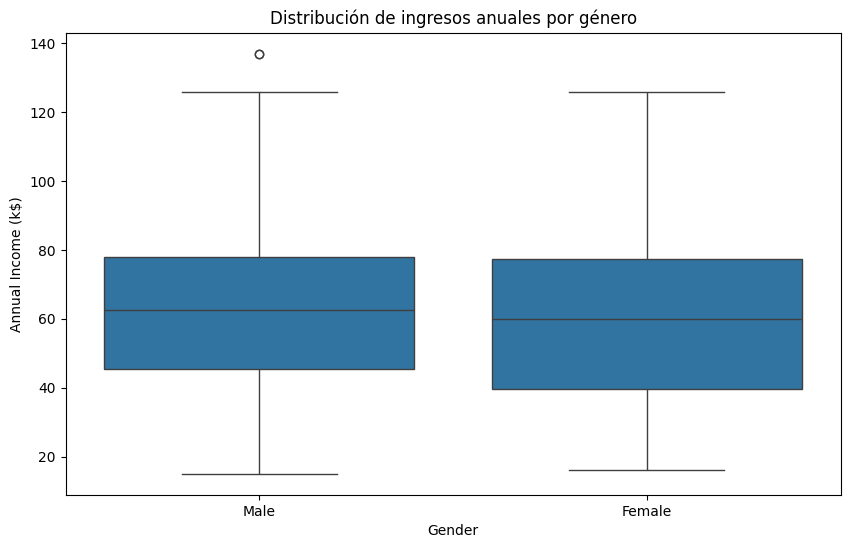

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Annual Income (k$)', data=df)
plt.title('Distribución de ingresos anuales por género')
plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

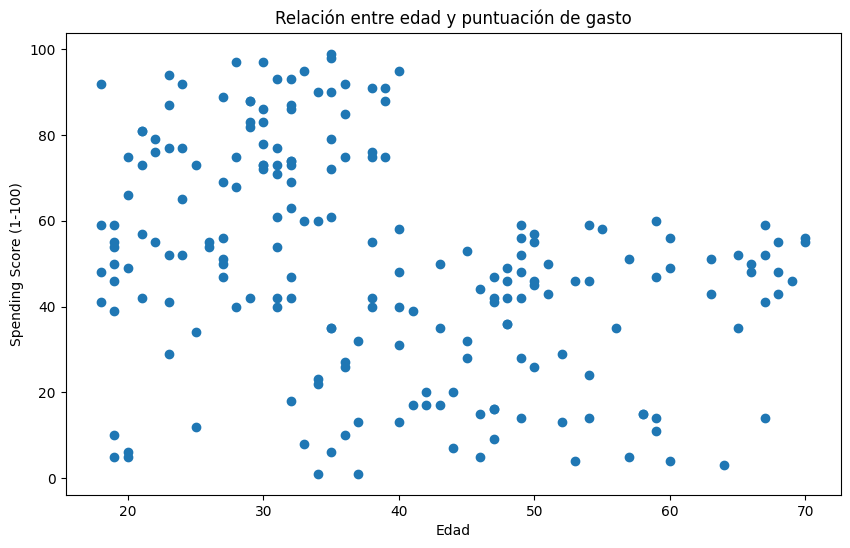

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Spending Score (1-100)'])
plt.title('Relación entre edad y puntuación de gasto')
plt.xlabel('Edad')
plt.ylabel('Spending Score (1-100)')
plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

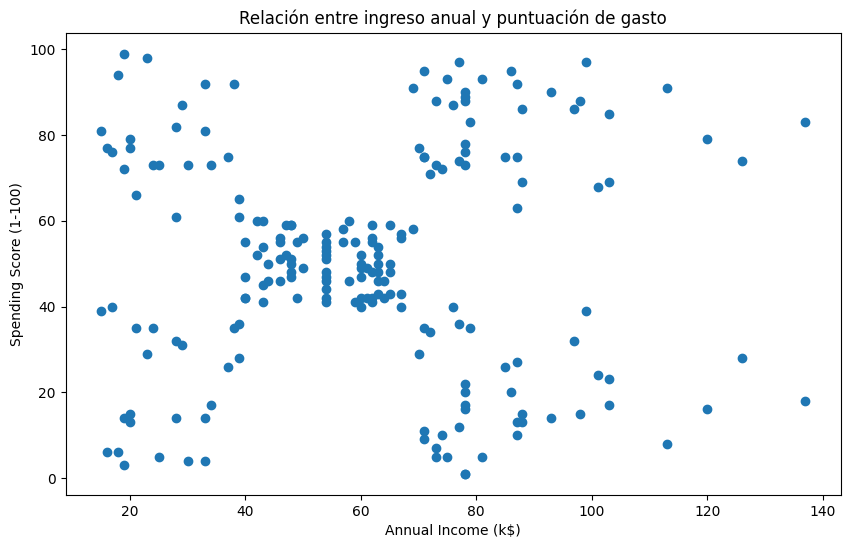

Coeficiente de correlación: 0.01


In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.title('Relación entre ingreso anual y puntuación de gasto')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

correlation = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f'Coeficiente de correlación: {correlation:.2f}')

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

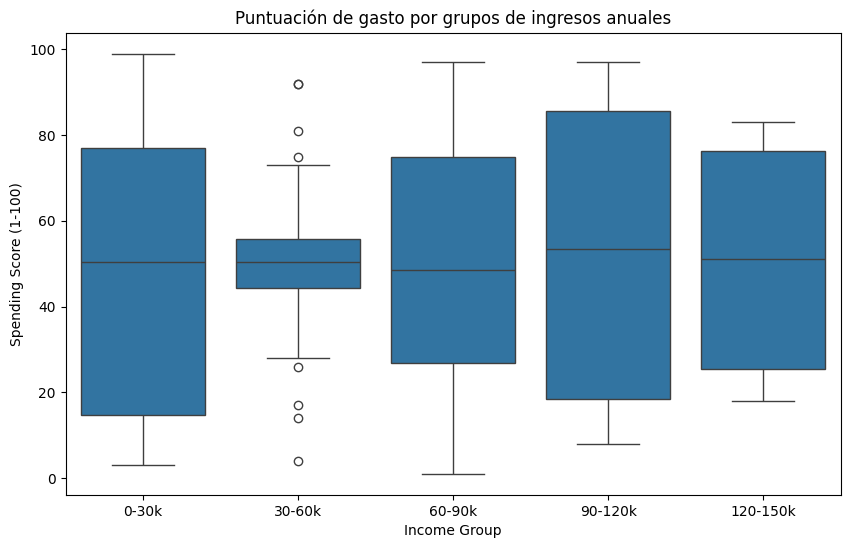

In [6]:
# Crear grupos de ingresos
bins = [0, 30, 60, 90, 120, 150]
labels = ['0-30k', '30-60k', '60-90k', '90-120k', '120-150k']
df['Income Group'] = pd.cut(df['Annual Income (k$)'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Income Group', y='Spending Score (1-100)', data=df)
plt.title('Puntuación de gasto por grupos de ingresos anuales')
plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

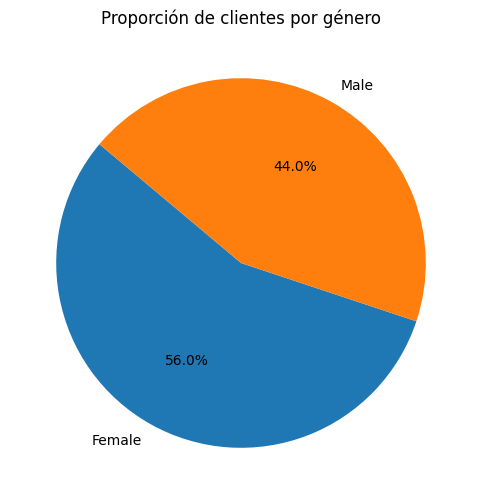

In [7]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proporción de clientes por género')
plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

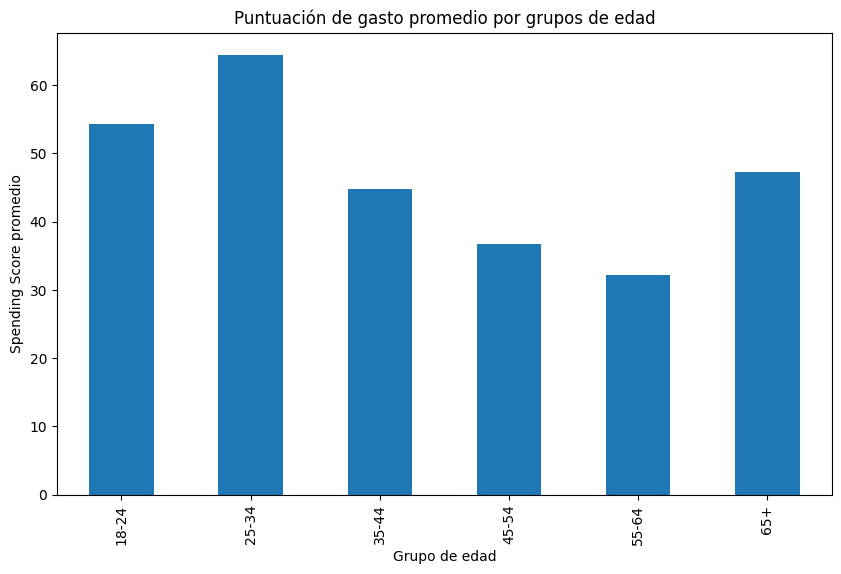

In [8]:
# Crear grupos de edad
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

avg_spending = df.groupby('Age Group')['Spending Score (1-100)'].mean()

plt.figure(figsize=(10, 6))
avg_spending.plot(kind='bar')
plt.title('Puntuación de gasto promedio por grupos de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score promedio')
plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

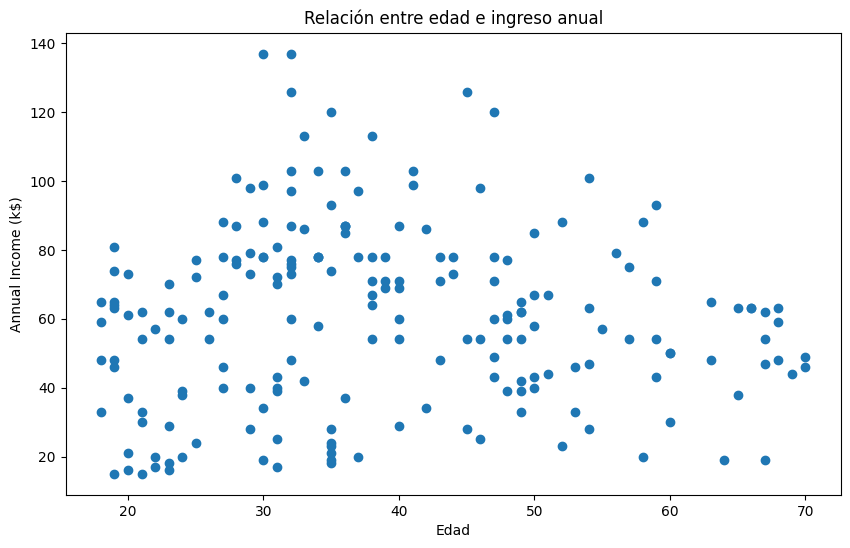

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Annual Income (k$)'])
plt.title('Relación entre edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Annual Income (k$)')
plt.show()

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

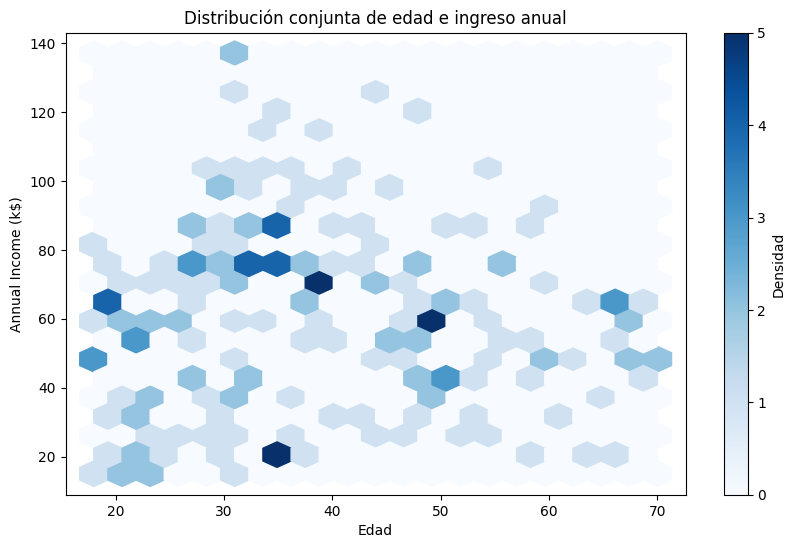

In [10]:
plt.figure(figsize=(10, 6))
plt.hexbin(df['Age'], df['Annual Income (k$)'], gridsize=20, cmap='Blues')
plt.colorbar(label='Densidad')
plt.title('Distribución conjunta de edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Annual Income (k$)')
plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

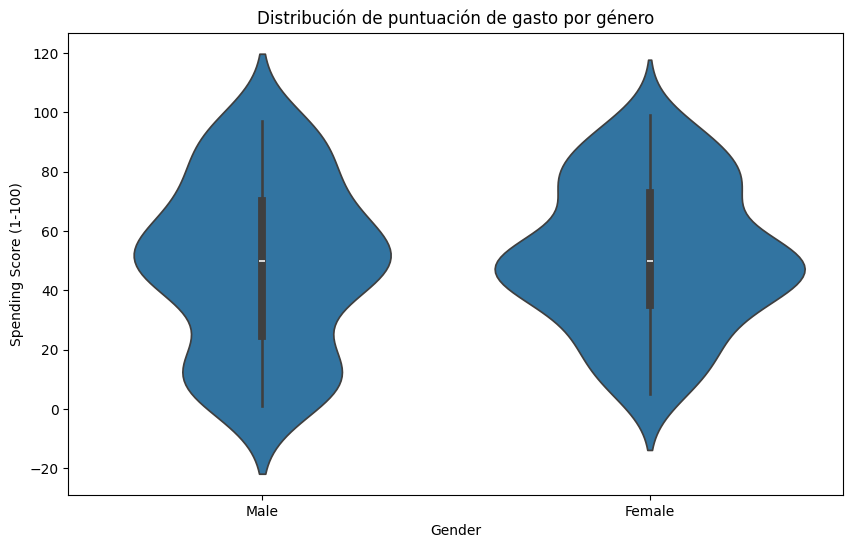

In [11]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title('Distribución de puntuación de gasto por género')
plt.show()